# MSHA — Maths & Data Science I
## Assignment — Distributions & Exploratory Analysis of Hospital Claims

AI-use disclosure: Claude (Anthropic) in Visual Studio was used to help develop the code in this notebook with manual additions, it was done working through the assignment part by part. The written interpretations are my own.


## Part A -  Load & Inspect.


1. Load the dataset and report its shape (rows × columns). 
2. Display the column names and their data types. Identify which columns holding dates 
are currently stored as text. 
3. Report the number of missing values per column and state which column(s) are affected. 
4. Print summary statistics for TotalExpenses and describe its distribution in one sentence 
(mean vs. median).



**A1.  Load the dataset and report its shape.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the claims data directly from the source URL given in the brief
url = ('https://github.com/thousandoaks/Python4DS-I/'
       'raw/main/datasets/HealthcareDataset_PublicRelease.csv')
df = pd.read_csv(url)
print('Shape (rows, columns):', df.shape)

Shape (rows, columns): (52563, 17)


**A2. Column dtypes — which date columns are stored as text?**

In [2]:
# Show every column and its data type
print(df.dtypes)

date_fields = ['StartDate', 'EndDate', 'BirthDate']
stored_as_text = [c for c in date_fields
                  if not pd.api.types.is_datetime64_any_dtype(df[c])]
print()
print('Date columns currently stored as text:', stored_as_text)

# Convert them now - the derived columns in Part B need proper datetimes
for col in date_fields:
    df[col] = pd.to_datetime(df[col])

Id                          int64
MemberName                    str
MemberID                      str
County                        str
MedicalClaim                  str
ClaimItem                   int64
HospitalName                  str
HospitalType                  str
StartDate                     str
EndDate                       str
PrincipalDiagnosisDesc        str
PrincipalDiagnosis            str
RevenueCodeDesc               str
RevenueCode               float64
TypeFlag                      str
BirthDate                     str
TotalExpenses             float64
dtype: object

Date columns currently stored as text: ['StartDate', 'EndDate', 'BirthDate']


*TODO — your own words: note which date columns arrived as text and why they must be converted before any date arithmetic.*

**A3. Missing values per column.**

In [3]:
missing = df.isna().sum()
cols_with_missing = list(missing[missing > 0].index)

print(missing)
print()
print('Number of columns with missing values:', len(cols_with_missing))
print('Columns with missing values:', cols_with_missing)
print('Total missing values:', int(missing.sum()))

Id                        0
MemberName                0
MemberID                  0
County                    0
MedicalClaim              0
ClaimItem                 0
HospitalName              0
HospitalType              0
StartDate                 0
EndDate                   0
PrincipalDiagnosisDesc    0
PrincipalDiagnosis        0
RevenueCodeDesc           2
RevenueCode               0
TypeFlag                  0
BirthDate                 0
TotalExpenses             0
dtype: int64

Number of columns with missing values: 1
Columns with missing values: ['RevenueCodeDesc']
Total missing values: 2


**A4. Summary statistics for TotalExpenses.**

In [4]:
df['TotalExpenses'].describe()

count     52563.000000
mean       2735.230373
std        8292.178928
min           0.000000
25%         194.642000
50%         675.262000
75%        2309.265000
max      504533.400000
Name: TotalExpenses, dtype: float64

*TODO - comparing the mean to the median and what that implies about skew.*

 The distribution is heavily right-skewed  the mean $2,735 sits about 4× above the median $675, so most line items are inexpensive while a small tail of very high-cost claims  drags the average upward.

## Part B - Derive the Analysis Variables
 
1. Write a function compute_age(birthdate, ref_date) that returns age in 
completed years. Apply it to create an Age column using a reference date of 
2020-12-31. 

2. Create a LengthOfStay column (in days) from EndDate − StartDate. 
3. Write a function that maps Age into a band ('<40', '40–64', '65–79', '80+') and apply it to 
create an AgeBand column. Report the count of line items in each band. 
4. Write a function cost_tier(x) that returns 'Low' (<$500), 'Medium' ($500–4,999), or 
'High' (≥$5,000), and apply it to TotalExpenses. Report the count in each tier. 
 

**B1. Age in completed years at 2020-12-31.**

In [5]:
def compute_age(birthdate, ref_date):
    """Return age in completed years at ref_date."""
    return (ref_date.year - birthdate.year
            - ((ref_date.month, ref_date.day) < (birthdate.month, birthdate.day)))

ref_date = pd.Timestamp('2020-12-31')
df['Age'] = df['BirthDate'].apply(lambda b: compute_age(b, ref_date))
df['Age'].describe()

count    52563.000000
mean        72.159123
std         12.230098
min         21.000000
25%         67.000000
50%         73.000000
75%         81.000000
max         99.000000
Name: Age, dtype: float64

**B2. LengthOfStay (days).**

In [6]:
# Length of stay in whole days from the service dates
df['LengthOfStay'] = (df['EndDate'] - df['StartDate']).dt.days
df['LengthOfStay'].describe()

count    52563.000000
mean         3.869109
std          6.008744
min          0.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        129.000000
Name: LengthOfStay, dtype: float64

**B3. Age bands.**

In [7]:
def age_band(age):
    """Map an age in years to its band."""
    if age < 40:
        return '<40'
    elif age < 65:
        return '40–64'
    elif age < 80:
        return '65–79'
    else:
        return '80+'

df['AgeBand'] = df['Age'].apply(age_band)
df['AgeBand'].value_counts()

AgeBand
65–79    27781
80+      14601
40–64     9444
<40        737
Name: count, dtype: int64

**B4. Cost tiers.**

In [8]:
def cost_tier(x):
    """Return 'Low' (<$500), 'Medium' ($500–4,999) or 'High' (>=$5,000)."""
    if x < 500:
        return 'Low'
    elif x < 5000:
        return 'Medium'
    else:
        return 'High'

df['CostTier'] = df['TotalExpenses'].apply(cost_tier)
df['CostTier'].value_counts()

CostTier
Low       22981
Medium    22948
High       6634
Name: count, dtype: int64

## Part C  -  Continuous 
Each plot must have a title and labeled axes. Add a one-sentence markdown interpretation 
under each. 
1. Histogram of TotalExpenses. Report the mean, median, standard deviation, and 
skewness. In 1–2 sentences, explain why the mean sits so far above the median. (The 
variable is highly skewed, so cap the x-axis to keep the shape visible.) 
2. Transform the skew. Because TotalExpenses is heavily right-skewed, create a 
log-transformed version (decide how to handle zero values and justify it) and plot its 
histogram. Compare the skewness before and after, and state what the transform 
reveals about the underlying shape. 
3. Histogram of Age. Describe its center and the direction of its skew, and report the share 
of line items for members aged 65 and over. 
4. Histogram of LengthOfStay (cap the axis or log-scale as needed for readability). 
Describe its shape and a typical value. 

5. Short synthesis (2–4 sentences): which variables are right-skewed, which is 
left-skewed, and why the shape matters when choosing between the mean and the 
median as a summary. 


**C1. Histogram of TotalExpenses with mean, median, std and skewness.**

Mean:        2735.23
Median:       675.26
Std dev:     8292.18
Skewness:      16.05


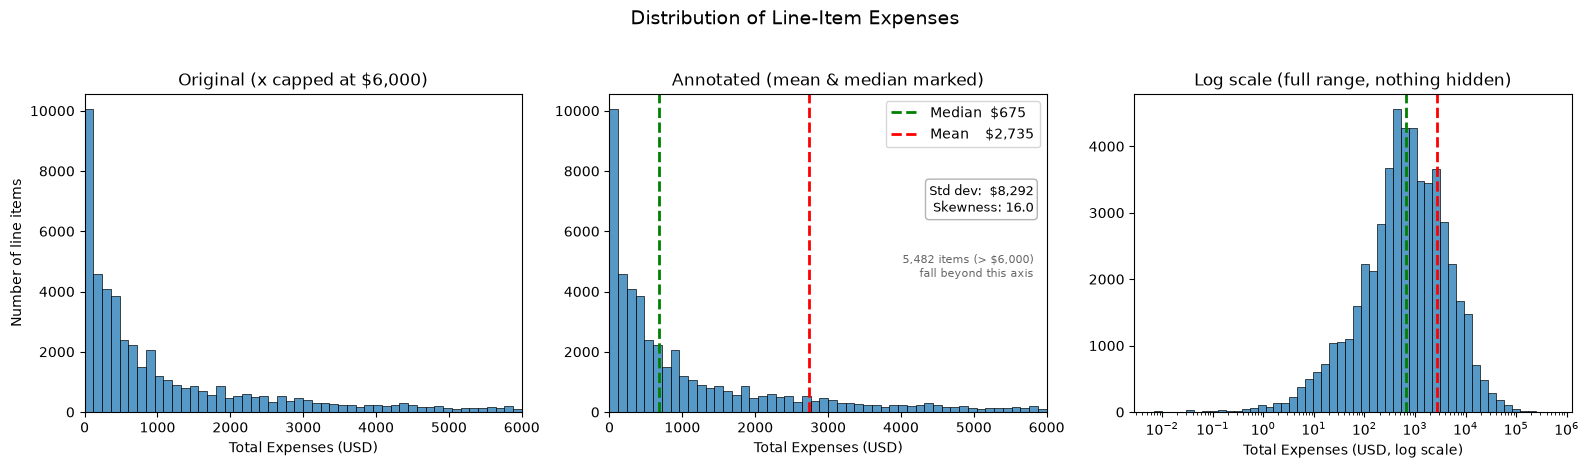

In [9]:
te = df['TotalExpenses']
CAP = 6000
mean, median, std, skew = te.mean(), te.median(), te.std(), te.skew()
clipped = (te > CAP).sum()

print(f'Mean:     {mean:>10.2f}')
print(f'Median:   {median:>10.2f}')
print(f'Std dev:  {std:>10.2f}')
print(f'Skewness: {skew:>10.2f}')

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: original chart, as it was
sns.histplot(x=te, bins=50, binrange=(0, CAP), ax=ax0)
ax0.set_xlim(0, CAP)
ax0.set_title('Original (x capped at $6,000)')
ax0.set_xlabel('Total Expenses (USD)'); ax0.set_ylabel('Number of line items')

# Panel 2: annotated with mean/median lines and a clip note
sns.histplot(x=te, bins=50, binrange=(0, CAP), ax=ax1)
ax1.set_xlim(0, CAP)
ax1.axvline(median, color='green', ls='--', lw=2, label=f'Median  ${median:,.0f}')
ax1.axvline(mean,   color='red',   ls='--', lw=2, label=f'Mean    ${mean:,.0f}')
ax1.legend()
ax1.text(0.97, 0.72, f'Std dev:  ${std:,.0f}\nSkewness: {skew:.1f}',
         transform=ax1.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax1.text(0.97, 0.50, f'{clipped:,} items (> ${CAP:,})\nfall beyond this axis',
         transform=ax1.transAxes, ha='right', va='top', fontsize=8, color='0.4')
ax1.set_title('Annotated (mean & median marked)')
ax1.set_xlabel('Total Expenses (USD)'); ax1.set_ylabel('')

# Panel 3: log scale, full range with nothing hidden
sns.histplot(x=te[te > 0], bins=50, log_scale=True, ax=ax2)
ax2.axvline(median, color='green', ls='--', lw=2)
ax2.axvline(mean,   color='red',   ls='--', lw=2)
ax2.set_title('Log scale (full range, nothing hidden)')
ax2.set_xlabel('Total Expenses (USD, log scale)'); ax2.set_ylabel('')

fig.suptitle('Distribution of Line-Item Expenses', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()



#*TODO - the mean sits so far above the median (what the long right tail does to the mean but not the median).*#

The distribution is right-skewed the vast majority of line items are small  clustered below the $675 median  there is a  long tail of rare, very high-cost claims pulls the mean up to $2,735, which is  four times the median, because the mean is sensitive to those extreme costs while the median is the the value and wouldn not move much.

Chart 1 -  (linear, capped at $6,000): You see the true shape of the common case  a tall spike of cheap items near $0 falling away steeply to the right. But it hides two things: where the average actually lands, and that 5,482 items cost more than $6,000 and are off-screen entirely.

Chart 2 Annotated (linear + lines): Same  as chart1 , but the green median line $675 sits inside the cluster while the red mean line $2,735 floats far out in the sparse tail to be meanful. That visible gap between the two lines reprents the main idenified skew.

Chart 3 - Log scale (full range): Plotting log(TotalExpenses) compress the tail and stretches the crowded low end, turning the skewed bell-like shape. Nothing is hidden.

## C2. Log transform.
** `TotalExpenses` contains a small number of zero-value line items, and log(0) is undefined — so we use `log1p` (log of 1 + x), which maps 0 to 0 and keeps every row rather than dropping them.**

Zero-value line items: 16
Skewness before transform: 16.05
Skewness after log1p:      -0.43


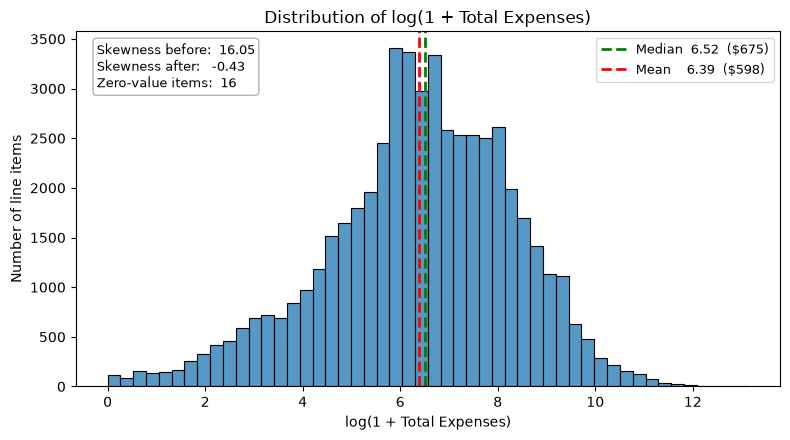

In [10]:
# How many zeros need handling?
zeros = int((te == 0).sum())
print('Zero-value line items:', zeros)

# log1p handles zeros: log1p(0) = 0, so no rows are lost
df['LogExpenses'] = np.log1p(te)
le = df['LogExpenses']

skew_before, skew_after = te.skew(), le.skew()
mean_l, median_l = le.mean(), le.median()
print(f'Skewness before transform: {skew_before:.2f}')
print(f'Skewness after log1p:      {skew_after:.2f}')

plt.figure(figsize=(8, 4.5))
ax = sns.histplot(x=le, bins=50)
ax.axvline(median_l, color='green', ls='--', lw=2,
           label=f'Median  {median_l:.2f}  (${np.expm1(median_l):,.0f})')
ax.axvline(mean_l,   color='red',   ls='--', lw=2,
           label=f'Mean    {mean_l:.2f}  (${np.expm1(mean_l):,.0f})')
ax.legend(loc='upper right', fontsize=9)
ax.text(0.03, 0.97,
        f'Skewness before:  {skew_before:.2f}\n'
        f'Skewness after:   {skew_after:.2f}\n'
        f'Zero-value items:  {zeros}',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.set_title('Distribution of log(1 + Total Expenses)')
ax.set_xlabel('log(1 + Total Expenses)')
ax.set_ylabel('Number of line items')
plt.tight_layout()
plt.show()


#*TODO - compare the skewness before and after the transform, and say what the roughly symmetric log-scale shape reveals about the underlying distribution (multiplicative / log-normal-like spread).*#

The log transform cuts the skewness from 16.05 to −0.43  from right-skew to almost perfectly symmetric both sides. On the log scale the values form a roughly symmetric, bell-shaped distribution with the mean and median nearly equal 6.4 verus 6.5 in log units, TotalExpenses is approximately log-normal. It  means costs vary multiplicatively rather than additively - claims differ by ratios for example "3× more" rather than fixed dollar amounts.


**C3. Histogram of Age and the share of line items for members 65+.**

Mean age:   72.2
Median age: 73.0
Skewness:   -0.87
Share of line items for members aged 65+: 80.6%


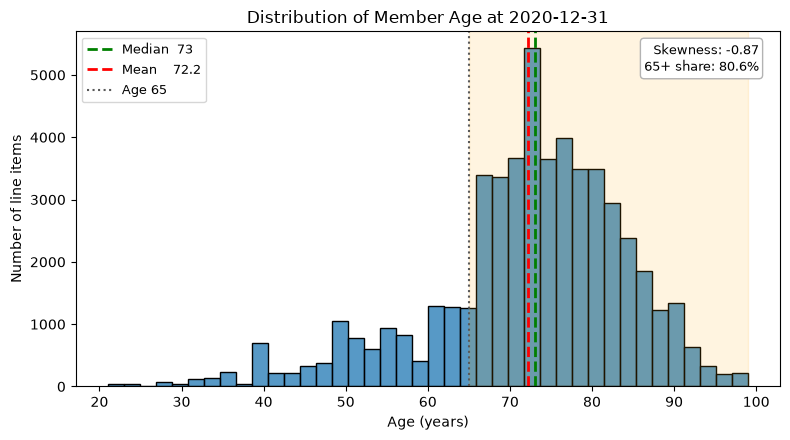

In [11]:
age = df['Age']
mean_a, median_a, skew_a = age.mean(), age.median(), age.skew()
share_65 = (age >= 65).mean()

print(f'Mean age:   {mean_a:.1f}')
print(f'Median age: {median_a:.1f}')
print(f'Skewness:   {skew_a:.2f}')
print(f'Share of line items for members aged 65+: {share_65:.1%}')

plt.figure(figsize=(8, 4.5))
ax = sns.histplot(x=age, bins=40)
ax.axvspan(65, age.max(), color='orange', alpha=0.12)          # shade the 65+ region
ax.axvline(median_a, color='green', ls='--', lw=2, label=f'Median  {median_a:.0f}')
ax.axvline(mean_a,   color='red',   ls='--', lw=2, label=f'Mean    {mean_a:.1f}')
ax.axvline(65, color='0.35', ls=':', lw=1.5, label='Age 65')
ax.legend(loc='upper left', fontsize=9)
ax.text(0.97, 0.97, f'Skewness: {skew_a:.2f}\n65+ share: {share_65:.1%}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.set_title('Distribution of Member Age at 2020-12-31')
ax.set_xlabel('Age (years)'); ax.set_ylabel('Number of line items')
plt.tight_layout()
plt.show()


*TODO  - describe the center of the age distribution and the direction of its skew (note the sign of the skewness statistic).*

The age distribution is centred on the mid-70s  approx  mean 72.2 and median 73 years,  so members are predominantly elderly 80.6% are aged 65 both mean and median are close and both in the low‑70s it shows a 65 plus share, its typically  what you would expect has people get older that's the typical age. Also note the Direction of skew shows  a negative skewness sign = tail on the left (younger) side; a positive sign would mean the tail points right. Age here is −0.87, so left‑skewed.

 The skewness is negative −0.87, meaning the distribution is left-skewed it shows the  the bulk of members cluster at older ages while a thin tail stretches down toward younger ages. This shows up in the statistics as the median 73 sitting slightly above the mean 72.2, the reverse of the right-skewed cost variables where the mean sat far above the median.

**C4. Histogram of LengthOfStay** (x-axis capped for readability).

Median stay: 2 days
Mean stay:   3.87 days
Skewness:    7.00
Maximum:     129 days


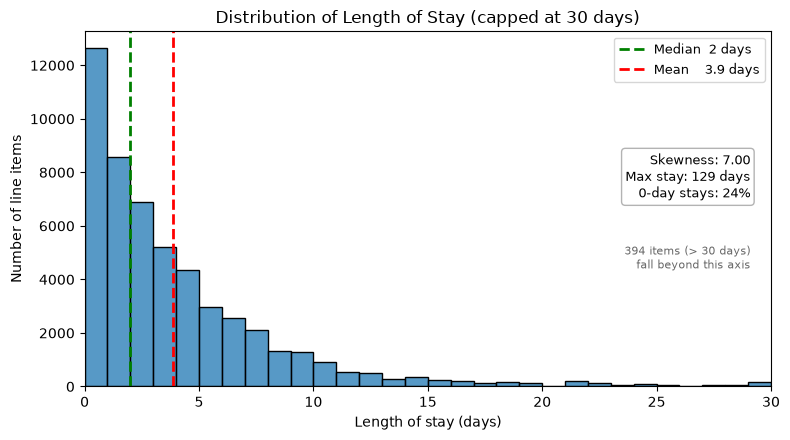

In [12]:
los = df['LengthOfStay']
CAP = 30
mean_l, median_l, skew_l, maxv = los.mean(), los.median(), los.skew(), los.max()
clipped = int((los > CAP).sum())
zero_share = (los == 0).mean()

print(f'Median stay: {median_l:.0f} days')
print(f'Mean stay:   {mean_l:.2f} days')
print(f'Skewness:    {skew_l:.2f}')
print(f'Maximum:     {maxv} days')

plt.figure(figsize=(8, 4.5))
ax = sns.histplot(x=los, bins=30, binrange=(0, CAP))
ax.set_xlim(0, CAP)
ax.axvline(median_l, color='green', ls='--', lw=2, label=f'Median  {median_l:.0f} days')
ax.axvline(mean_l,   color='red',   ls='--', lw=2, label=f'Mean    {mean_l:.1f} days')
ax.legend(loc='upper right', fontsize=9)
ax.text(0.97, 0.66, f'Skewness: {skew_l:.2f}\nMax stay: {maxv} days\n0-day stays: {zero_share:.0%}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.text(0.97, 0.40, f'{clipped:,} items (> {CAP} days)\nfall beyond this axis',
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='0.4')
ax.set_title('Distribution of Length of Stay (capped at 30 days)')
ax.set_xlabel('Length of stay (days)'); ax.set_ylabel('Number of line items')
plt.tight_layout()
plt.show()


#*TODO — Describe the shape of the stay distribution and a typical value.*#

The length of stay distribution is strongly right-skewed 7.00  most line items involve very short stays  the tallest bar is at 0 days n need to stay in, about 24% are same-day 0-day stays, and the majority of the  is in the 0–5 day range  While a long thin tail of extended admissions of various lengths runs out to a maximum of 129 days found in this data. A typical value is best given by the median on this represetation  of 2 days rather than the mean of 3.9 days, since the mean is inflated by that small number of very long stays.

In summary 
Shape shows a positive skew, tall spike near zero, long right tail  and  most short, a few very long.   3.9 mean  being used would overstate state a normal stay.

**C5. Synthesis.**

*TODO - which variables are right-skewed, which is left-skewed, and why the shape matters when choosing between the mean and the median as a summary statistic.*

Shape matters because it determines whether the mean actually represents a "typical" value  or badly misleads you into making false assumptions. 

1. The mean and median react differently to extreme values.

The mean adds up every value and divides so every data point pulls on it, and a few larger values pull hard. It has no resistance to outliers.
The median is just the middle value when sorted it only cares about how many values sit above/below it. One claim of $500,000 counts the same as one of $5,000: both are "one value above the middle." It's resistant to outliers.

2. So in the cirumstance of a  a skewed distribution, the two diverge  and one of them can be distorted to give misleading answers.

 'TotalExpenses' showed a median $675 and  mean $2,735. If you reported "the average line item costs $2,735," you'd be describing a value that almost no actual line item is near most sit far below it, and it's only that high because a handful of six-figure claims drag it up. The mean is a real number, but it's not typical within the data. The median at  $675 is what a normal claim actually looks like and would be more accurate.

3. In a symmetric distribution, shape stops mattering  they agree

in the case of 'Age' it was near-symmetric, with a  mean  of 72.2  and  median 73. When the tails balance, the outliers on each side cancel out in the mean, so both measures land in the same place and either is fine to be used.

4. The direction of skew tells you which way the mean is wrong.

Right-skewed  showed 'expenses', 'stay' using the tail on the high side  and  mean against  median showed the mean overstates the typical value that should be expected.

Left-skewed 'age' tail on the low side  mean less than  median distorts  the mean and  understates the actual true value. Shape decides whether the mean is a fair summary or a distortion  so you check the skew first, then pick the statistic that honestly represents the data and that allows you to get a better clearer picture of what is typical.

## Part D — Discrete Distributions

**D1. Billing-category frequency (RevenueCodeDesc).**

Distinct billing categories: 131
Share of all line items covered by the top ten: 57.0%

RevenueCodeDesc
LABORATORY - CLINICAL DIAGNOSTIC: CHEMISTRY                    5857
EMERGENCY ROOM                                                 4277
LABORATORY - CLINICAL DIAGNOSTIC: HEMATOLOGY                   4037
DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DETAIL CODING       3475
PHARMACY                                                       3109
EKG/ECG                                                        2027
RADIOLOGY - DIAGNOSTIC: CHEST X-RAY                            1862
LABORATORY - CLINICAL DIAGNOSTIC: BACTERIOLOGY/MICROBIOLOGY    1831
LABORATORY - CLINICAL DIAGNOSTIC                               1791
MEDICAL/SURGICAL SUPPLIES: STERILE SUPPLIES                    1697
Name: count, dtype: int64


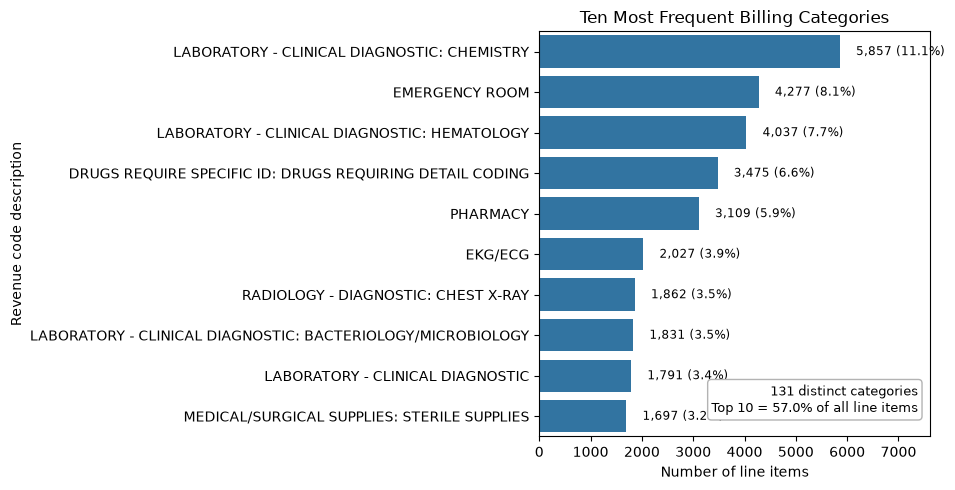

In [13]:
n = len(df)
rev_counts = df['RevenueCodeDesc'].value_counts()
ncat = df['RevenueCodeDesc'].nunique()
top10 = rev_counts.head(10)
top10_share = top10.sum() / n

print('Distinct billing categories:', ncat)
print(f'Share of all line items covered by the top ten: {top10_share:.1%}')
print()
print(top10)

plt.figure(figsize=(9.5, 5))
ax = sns.barplot(x=top10.values, y=top10.index)
for i, v in enumerate(top10.values):                       # count + % on each bar
    ax.text(v + n*0.006, i, f'{v:,} ({v/n:.1%})', va='center', fontsize=8.5)
ax.text(0.97, 0.05, f'{ncat} distinct categories\nTop 10 = {top10_share:.1%} of all line items',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.set_xlim(0, top10.values.max() * 1.30)                  # headroom for labels
ax.set_title('Ten Most Frequent Billing Categories')
ax.set_xlabel('Number of line items'); ax.set_ylabel('Revenue code description')
plt.tight_layout()
plt.show()


*TODO -what dominates the billing mix (e.g. routine lab / pharmacy items) and what the top-ten share says about concentration.*

Of 131 distinct billing categories, the top ten account for 57% of all line items and are dominated by routine diagnostic and support services the rest laboratory tests (chemistry, hematology, microbiology), emergency-room charges, and pharmacy with Lab–Chemistry the single most common at 11.1%.
The top bars are overwhelmingly lab/diagnostic codes plus ER and pharmacy are  all high-volume, low-cost routine services, the 57% / 131 categories figures show the distribution is concentrated: a handful of common service types account for most line items, with a long tail of rare ones.

**D2. Count distribution- ER visits per member.** Distinct ER claims are counted per member; members with claims in the data but no ER claims are included as zeros.

Members: 1757
Mean ER visits per member:     1.065
Variance of ER visits:         2.186
Fraction with zero ER visits:  33.1%


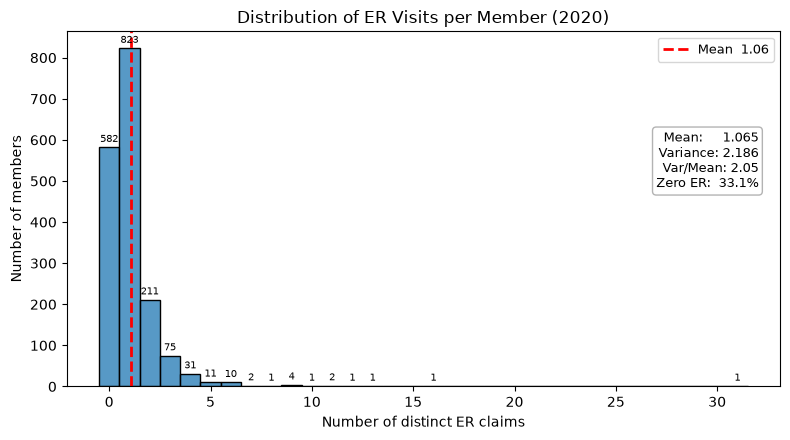

In [14]:
all_members = df['MemberID'].unique()
er_per_member = (df[df['TypeFlag'] == 'ER']
                 .groupby('MemberID')['MedicalClaim'].nunique()
                 .reindex(all_members, fill_value=0))

mean_v, var_v = er_per_member.mean(), er_per_member.var()
zero_frac = (er_per_member == 0).mean()

print('Members:', len(er_per_member))
print(f'Mean ER visits per member:     {mean_v:.3f}')
print(f'Variance of ER visits:         {var_v:.3f}')
print(f'Fraction with zero ER visits:  {zero_frac:.1%}')

plt.figure(figsize=(8, 4.5))
ax = sns.histplot(x=er_per_member, bins=range(0, er_per_member.max() + 2), discrete=True)
ax.axvline(mean_v, color='red', ls='--', lw=2, label=f'Mean  {mean_v:.2f}')
ax.legend(loc='upper right', fontsize=9)
counts = er_per_member.value_counts().sort_index()          # count labels on bars
for k, c in counts.items():
    if c > 0:
        ax.text(k, c + len(er_per_member)*0.004, f'{c:,}', ha='center', va='bottom', fontsize=7.5)
ax.text(0.97, 0.72, f'Mean:     {mean_v:.3f}\nVariance: {var_v:.3f}\n'
                    f'Var/Mean: {var_v/mean_v:.2f}\nZero ER:  {zero_frac:.1%}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.set_title('Distribution of ER Visits per Member (2020)')
ax.set_xlabel('Number of distinct ER claims'); ax.set_ylabel('Number of members')
plt.tight_layout()
plt.show()


*TODO - the count distribution (most members have 0–1 visits; a small tail has many).*

ER visits per member form a right-skewed count distribution centred near zero a third of members had no ER visit and most of the rest had just one mean  1.06  with a long tail of rare frequent-users reaching 31 visits, and the variance (2.19) running about twice the mean, a first sign of overdispersion relative to a Poisson process. Looking at the chart and number about About a third of members 33.1% (582 of 1,757)  had no ER visits at all in 2020.



## **D3. Count distribution - diagnoses per member(Distinct principal diagnoses per member.**

Mean diagnoses per member:        1.772
Variance:                         2.212
Maximum:                          23
Members with exactly 1 diagnosis: 62.8%


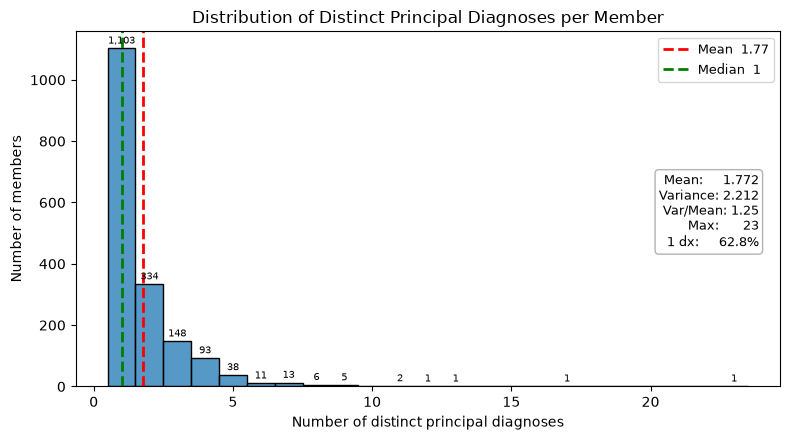

In [15]:
dx_per_member = df.groupby('MemberID')['PrincipalDiagnosis'].nunique()
mean_v, var_v, maxv, median_v = dx_per_member.mean(), dx_per_member.var(), dx_per_member.max(), dx_per_member.median()
one_dx = (dx_per_member == 1).mean()          # fraction of members with exactly one diagnosis

print(f'Mean diagnoses per member:        {mean_v:.3f}')
print(f'Variance:                         {var_v:.3f}')
print(f'Maximum:                          {maxv}')
print(f'Members with exactly 1 diagnosis: {one_dx:.1%}')   # -> 62.8%

plt.figure(figsize=(8, 4.5))
ax = sns.histplot(x=dx_per_member, bins=range(1, maxv + 2), discrete=True)
ax.axvline(mean_v,   color='red',   ls='--', lw=2, label=f'Mean  {mean_v:.2f}')
ax.axvline(median_v, color='green', ls='--', lw=2, label=f'Median  {median_v:.0f}')
ax.legend(loc='upper right', fontsize=9)
counts = dx_per_member.value_counts().sort_index()
for k, c in counts.items():
    if c > 0:
        ax.text(k, c + len(dx_per_member)*0.004, f'{c:,}', ha='center', va='bottom', fontsize=7.5)
ax.text(0.97, 0.60, f'Mean:     {mean_v:.3f}\nVariance: {var_v:.3f}\n'
                    f'Var/Mean: {var_v/mean_v:.2f}\nMax:      {maxv}\n'
                    f'1 dx:     {one_dx:.1%}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.set_title('Distribution of Distinct Principal Diagnoses per Member')
ax.set_xlabel('Number of distinct principal diagnoses'); ax.set_ylabel('Number of members')
plt.tight_layout()
plt.show()



##*TODO  summarise this distribution.*##

Most members  shown above have just a single principal diagnosis 62.8% and  median calculated as  1,  and mean 1.77.   The count distribution right-skewed again like previously is  tailing off to a  maximum of 23, and its variance based off the data is  2.21 only slightly above the mean  so it's mildly overdispersed but close to the ideal  Poisson distribution which would clear desribe the probability of constant mean rate.





**D4. Poisson check. A Poisson distribution has variance equal to its mean; variance above the mean indicates overdispersion.**



In [16]:
for name, s in [('ER visits per member', er_per_member),
                ('Diagnoses per member', dx_per_member)]:
    ratio = s.var() / s.mean()
    verdict = 'overdispersed' if ratio > 1 else 'not overdispersed'
    print(f'{name}: mean = {s.mean():.3f}, variance = {s.var():.3f}, '
          f'variance/mean = {ratio:.2f} → {verdict}')

ER visits per member: mean = 1.065, variance = 2.186, variance/mean = 2.05 → overdispersed
Diagnoses per member: mean = 1.772, variance = 2.212, variance/mean = 1.25 → overdispersed


*TODO - whether each count distribution is overdispersed relative to Poisson, and what overdispersion suggests (heterogeneity across members ? some are much heavier users than a single-rate Poisson would allow).*

Both measures show more variation than we would expect from a Poisson distribution,  this is because the variance is higher than the mean in each case. For ER visits, the mean is about 1.07 and the variance is 2.19, giving a variance to mean ratio of approx 2.05. For distinct diagnoses as shown above, the mean is about 1.77 and the variance is 2.21, giving a ratio of around 1.25.

This suggests that members do not all have the same underlying rate of ER visits or diagnoses. Most members have relatively few, while a smaller number have much higher counts.  A Poisson process dstribution assumes every member shares a single constant event rate, which will  forces the variance to equal the mean.   In this case the excess variance here shows that assumption does not hold This is most  noticeable for ER visits, where the variance is roughly twice the mean. The diagnosis counts show much less over dispersion across the charts above and are therefore closer to what we would expect under a Poisson distribution.

## Part E - Relationships & Concentration##

**E1. Correlation matrix and the effect of aggregation grain.**

               TotalExpenses    Age  LengthOfStay
TotalExpenses          1.000  0.027         0.268
Age                    0.027  1.000         0.096
LengthOfStay           0.268  0.096         1.000


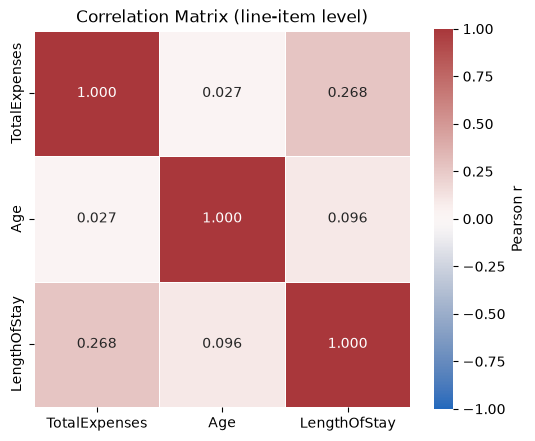

Line-item level corr(cost, stay): 0.268
Claim level corr(cost, stay):     0.786


In [17]:
corr = df[['TotalExpenses', 'Age', 'LengthOfStay']].corr()
print(corr.round(3))

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='vlag', vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Matrix (line-item level)')
plt.tight_layout()
plt.show()

# Claim-level: one row per claim, cost summed, stay length taken once
claims = (df.groupby('MedicalClaim')
            .agg(ClaimTotal=('TotalExpenses', 'sum'),
                 LengthOfStay=('LengthOfStay', 'first')))
claim_corr = claims['ClaimTotal'].corr(claims['LengthOfStay'])
print(f'Line-item level corr(cost, stay): {corr.loc["TotalExpenses", "LengthOfStay"]:.3f}')
print(f'Claim level corr(cost, stay):     {claim_corr:.3f}')


*TODO —  the cost–stay correlation jumps so much at the claim level (a long stay generates many cheap line items individually, but a large total once they are summed).*

At the line-item level, there isn’t a particularly strong relationship between any of the variables. Cost and length of stay have the strongest correlation at 0.268, while cost and age are barely related at 0.027. Age and length of stay also have only a weak relationship at 0.096.

The picture changes when the data is grouped by claim. The correlation between cost and length of stay rises from 0.268 to 0.786, showing a much stronger relationship. This makes sense because a longer stay will usually have lots of separate charges. When these are looked at individually, the link between cost and length of stay is less obvious. But when all the charges for a claim are added together, it becomes much clearer that longer stays generally cost more.

Long stay produces many individually cheap line items, so per-line cost barely tracks duration; once those items are summed into a claim total, a longer stay accumulates more charges and a larger total, making the cumulative relationship much clearer when shown on the chart. The relationship was and is  always present  the line-item grain simply masked it, and aggregating to the claim level reveals it.

**E2. Diagnosis → cost, two ways.** The mean-cost ranking is restricted to diagnoses with at least 50 line items so that a handful of records cannot dominate the average — a judgement call; any similar threshold is defensible.

In [18]:
by_dx = (df.groupby('PrincipalDiagnosisDesc')['TotalExpenses']
           .agg(total_spend='sum', mean_cost='mean', line_items='count'))

print('Top ten diagnoses by TOTAL spend:')
print(by_dx.sort_values('total_spend', ascending=False)
           .head(10)[['total_spend', 'line_items']].round(0))
print()
print('Top ten diagnoses by MEAN cost per line item (min 50 line items):')
print(by_dx[by_dx['line_items'] >= 50]
           .sort_values('mean_cost', ascending=False)
           .head(10)[['mean_cost', 'line_items']].round(0))

Top ten diagnoses by TOTAL spend:
                           total_spend  line_items
PrincipalDiagnosisDesc                            
Sepsis unspecified organi   10131632.0        2046
Non-ST elevation (NSTEMI)    6036035.0         992
Atherosclerotic heart dis    5258583.0        1241
Hypertensive heart and ch    3996002.0        1126
Type 2 diabetes mellitus     3492961.0        1011
Cerebral infarction due t    3309356.0         674
Hypertensive heart diseas    3044502.0         972
COVID-19                     2930786.0        1064
Acute kidney failure unsp    2822044.0        1017
Other chest pain             2626890.0        2608

Top ten diagnoses by MEAN cost per line item (min 50 line items):
                           mean_cost  line_items
PrincipalDiagnosisDesc                          
Rheumatic disorders of bo    15022.0          62
Benign neoplasm of pituit    10334.0          61
Nonrheumatic aortic (valv     9876.0         110
Osteomyelitis of vertebra     9280.0      

*TODO -  how the two lists differ — which conditions are high-volume (e.g. sepsis, cardiac disease) versus high-unit-cost (e.g. surgical/orthopaedic conditions).*

The two lists are quite different because they are looking at cost from two different angles and  are quite different because they are measuring different things. The total-spend list is mostly made up of common conditions such as sepsis, NSTEMI, heart disease, hypertension, type 2 diabetes, stroke and COVID-19. These conditions may not have the highest cost each time they appear, but they occur frequently, so the costs quickly add up by the sheer muliples.

The mean_cost list is different. It includes conditions such as rheumatic bone disorders, pituitary neoplasm, aortic valve disease and spinal conditions. These occur less often, but individual treatments can be much more expensive, particularly where surgery or specialist procedures are involved.

The two lists are quite different because they are looking at cost from two different angles.

The total_spend list shows where most of the money is being spent overall. Conditions such as sepsis, heart disease, diabetes, stroke and COVID-19 appear near the top because they occur frequently. They may not always be particularly expensive on an individual line item, but the high number of cases means the costs add up quickly. For example, sepsis accounts for around $10.1 million across 2,046 line items.

The average_cost list tells a different story. It includes conditions such as rheumatic bone disorders, pituitary neoplasms, aortic valve disease and spinal conditions. These are much less common, but each individual case tends to be more expensive, often because treatment involves surgery, specialist care or more complex procedures.

The main takeaway is that high overall spending does not necessarily mean a condition is expensive to treat each time. Some conditions cost a lot overall because they are common, while others are costly because each individual case is expensive. This explains and is the main reason why there is very little overlap between the two lists



**E3. Geographic concentration.**

In [19]:
county = (df.groupby('County')['TotalExpenses']
            .agg(total_spend='sum', mean_cost='mean', line_items='count'))
county['share']      = county['total_spend'] / county['total_spend'].sum()   # share of spend
county['item_share'] = county['line_items']  / county['line_items'].sum()     # share of line items
county = county.sort_values('total_spend', ascending=False)

print('Counties:', len(county))
print(county[['share', 'item_share', 'mean_cost', 'line_items']].round(3).head(10))
print()
print(f"Cumulative spend share of the top five counties: {county['share'].head(5).sum():.1%}")
print(f"Cumulative item  share of the top five counties: {county['item_share'].head(5).sum():.1%}")
print(f"Overall mean cost per line item: {df['TotalExpenses'].mean():.0f}")


Counties: 19
          share  item_share  mean_cost  line_items
County                                            
02af982d  0.485       0.448   2961.022       23525
425a37b2  0.166       0.180   2523.756        9468
fd218584  0.114       0.102   3068.508        5349
89e38653  0.062       0.072   2349.649        3767
b021dd12  0.042       0.051   2249.052        2679
6f943458  0.041       0.035   3209.269        1849
e6708950  0.029       0.031   2626.775        1613
7d9b432e  0.016       0.016   2756.528         838
ea48569b  0.011       0.026   1183.121        1367
6f0b5b6c  0.010       0.011   2507.676         555

Cumulative spend share of the top five counties: 86.8%
Cumulative item  share of the top five counties: 85.2%
Overall mean cost per line item: 2735


*TODO - is the concentration driven more by volume or by price? (Compare the top counties' mean cost per line item to the overall mean, versus their share of line items.)*

Looking at the table above most of the spending is concentrated in the top five counties, but this is mainly because they have more claims rather than higher costs. Looking at them Together, they account for 86.8% of total spending and 85.2% of all line items in the above table. The largest county alone accounts for around 45% of the line items shown.

To support this the average cost per item in these counties is also fairly close to the overall average of $2,735, so there is no clear sign that they are more expensive than other areas.

To sumamrise these counties account for more spending because they handle a much larger volume of claims, not because individual claims cost more.  but thi his is also shown by the fact that their share of total spending is very similar to their share of line items.

**E4. Age → cost.**

In [20]:
band_order = ['<40', '40–64', '65–79', '80+']
by_band = (df.groupby('AgeBand')['TotalExpenses']
             .agg(mean_cost='mean', total_spend='sum')
             .reindex(band_order))
by_band['spend_share'] = by_band['total_spend'] / by_band['total_spend'].sum()
print(by_band.round(2))
print()
print(f'Correlation between Age and TotalExpenses: '
      f'{df["Age"].corr(df["TotalExpenses"]):.4f}')

         mean_cost  total_spend  spend_share
AgeBand                                     
<40        1324.00    975784.81         0.01
40–64      2020.79  19084387.66         0.13
65–79      2997.55  83274957.99         0.58
80+        2769.45  40436783.64         0.28

Correlation between Age and TotalExpenses: 0.0273


*TODO — your own words: 2–4 sentences reconciling the two findings: which age bands hold most of the total spend, and does age meaningfully predict the cost of an individual line item (look at how small the correlation is)?*

**E5. Closing insight.**

*TODO — your own words: 3–5 sentences pulling Parts C–E together: what concentrates spending in this population (a small high-cost tail of claims, a mostly elderly membership, volume-driven geographic concentration, overdispersed utilisation), and one follow-up question you would investigate.*